In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Charter", "Bitstream Charter"],
    "font.style": "normal",
})

### Residuals Comparison

In [7]:
age_test_folder = '../output/age_predictor/performance_tests/'

gyro = pd.read_csv(age_test_folder + 'gyro-multiscale/gyro_kfold_predictions.csv')
baseline = pd.read_csv(age_test_folder + 'baseline-multiscale/kfold_predictions.csv')
unet = pd.read_csv(age_test_folder + 'unet-multiscale/kfold_predictions.csv')
lw_conv = pd.read_csv(age_test_folder + 'lightweight_conv-multiscale/kfold_predictions.csv')
stellar_props = pd.read_csv(age_test_folder + 'stellar_props-multiscale/kfold_predictions.csv')
props_unet = pd.read_csv(age_test_folder + 'props_unet-multiscale/kfold_predictions.csv')
long_curve = pd.read_csv(age_test_folder + 'long_curve-multiscale/kfold_predictions.csv')
baseline_long = pd.read_csv(age_test_folder + 'baseline-long-multiscale/kfold_predictions.csv')
cf_final = pd.read_csv(age_test_folder + 'cf-final-multiscale/kfold_predictions.csv')

scatter_gyro = np.nanstd(gyro['log_residual'])
scatter_baseline = np.nanstd(baseline['log_residual'])
scatter_unet = np.nanstd(unet['log_residual'])
scatter_lw_conv = np.nanstd(lw_conv['log_residual'])
scatter_stellar_props = np.nanstd(stellar_props['log_residual'])
scatter_props_unet = np.nanstd(props_unet['log_residual'])
scatter_long_curve = np.nanstd(long_curve['log_residual'])
scatter_baseline_long = np.nanstd(baseline_long['log_residual'])
scatter_cf_final = np.nanstd(cf_final['log_residual'])

### Plot

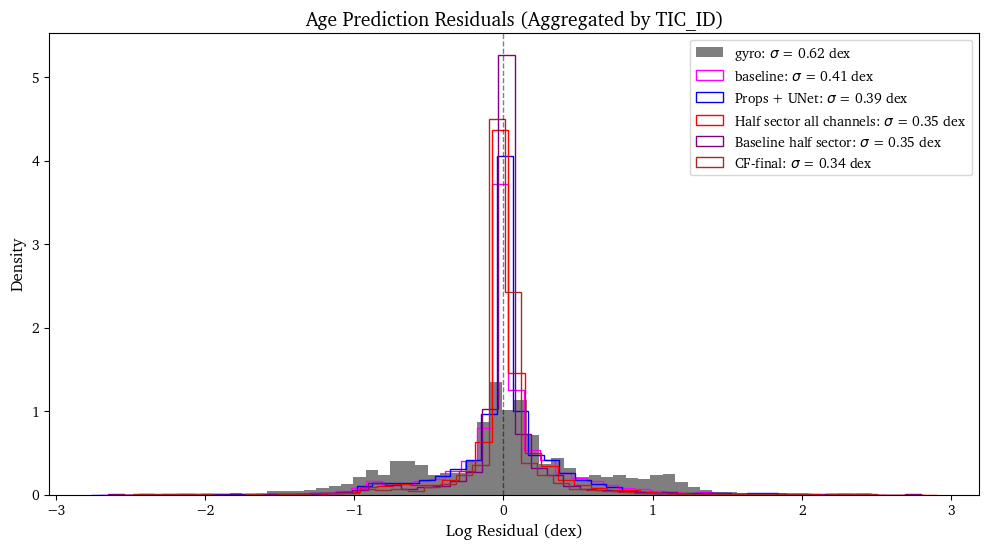

In [8]:
plt.figure(figsize=(12, 6))

plt.hist(gyro['log_residual'], bins=50, alpha=0.5, label=r'gyro: $\sigma$ = {:.2f} dex'.format(scatter_gyro), color='black',density=True)
plt.hist(baseline['log_residual'], bins=50, label=r'baseline: $\sigma$ = {:.2f} dex'.format(scatter_baseline), color='magenta',density=True,
         histtype='step',edgecolor='magenta',linewidth=1, alpha=1)
# plt.hist(unet['log_residual'], bins=50, label=r'UNet: $\sigma$ = {:.2f} dex'.format(scatter_unet), color='cyan',density=True,
#          histtype='step',edgecolor='cyan',linewidth=1, alpha=1)
# plt.hist(lw_conv['log_residual'], bins=50, label=r'Lightweight Conv: $\sigma$ = {:.2f} dex'.format(scatter_lw_conv), color='orange',density=True,
#          histtype='step',edgecolor='orange',linewidth=1, alpha=1)
# plt.hist(stellar_props['log_residual'], bins=50, label=r'Stellar Props: $\sigma$ = {:.2f} dex'.format(scatter_stellar_props), color='green',density=True,
#          histtype='step',edgecolor='green',linewidth=1, alpha=1)
plt.hist(props_unet['log_residual'], bins=50, label=r'Props + UNet: $\sigma$ = {:.2f} dex'.format(scatter_props_unet), color='blue',density=True,
         histtype='step',edgecolor='blue',linewidth=1, alpha=1)
plt.hist(long_curve['log_residual'], bins=50, label=r'Half sector all channels: $\sigma$ = {:.2f} dex'.format(scatter_long_curve), color='red',density=True,
         histtype='step',edgecolor='red',linewidth=1, alpha=1)
plt.hist(baseline_long['log_residual'], bins=50, label=r'Baseline half sector: $\sigma$ = {:.2f} dex'.format(scatter_baseline_long), color='purple',density=True,
         histtype='step',edgecolor='purple',linewidth=1, alpha=1)
plt.hist(cf_final['log_residual'], bins=50, label=r'CF-final: $\sigma$ = {:.2f} dex'.format(scatter_cf_final), color='brown',density=True,
         histtype='step',edgecolor='brown',linewidth=1, alpha=1)

plt.xlabel('Log Residual (dex)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Age Prediction Residuals (Aggregated by TIC_ID)', fontsize=14)
plt.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
plt.legend()
plt.show()